
# **Lab #1: การจัดการข้อมูลพื้นฐาน**
## **วัตถุประสงค์**
1. เรียนรู้การใช้งาน Python เบื้องต้นสำหรับการจัดการข้อมูล
2. เรียนรู้การใช้ไลบรารีสำคัญ เช่น Pandas และ GeoPandas
3. เรียนรู้การอ่าน/เขียนและสำรวจข้อมูลทางภูมิศาสตร์ (GeoData)

---
หมายเหตุ บางครั้งอาจจะเจอ Bug. ขอจงอย่าย่อท้อ ให้ใช้ทรัพยากรที่มีอยู่ในการจัดการแก้ไขปัญหา เช่น  Gemini หรือ ChatGPT แต่ทั้งนี้ต้องทำความเข้าใจกับคำตอบที่ได้ เพราะบางครั้ง AI ก็ให้คำตอบแบบงงๆ



## **1. การเริ่มต้นใช้งาน Google Colab**
### **1.1 เชื่อมต่อ Google Drive**
ก่อนอื่น ให้เชื่อมต่อ Google Drive เพื่อจัดเก็บข้อมูลของคุณ
    

In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive



### **1.2 ติดตั้งไลบรารีที่จำเป็น**
ติดตั้งไลบรารีที่จำเป็นสำหรับการจัดการข้อมูลและการวิเคราะห์ข้อมูลภูมิศาสตร์
    

In [ ]:

!pip install pandas geopandas matplotlib



## **2. การจัดการข้อมูลตารางด้วย Pandas**
### **2.1 สร้าง DataFrame ตัวอย่าง**
ลองสร้าง DataFrame ข้อมูลประชากรของประเทศในภูมิภาค ASEAN
    

In [ ]:

import pandas as pd

# สร้าง DataFrame ตัวอย่าง
data = {
    'ประเทศ': ['ไทย', 'ลาว', 'กัมพูชา', 'เวียดนาม','เมียนมาร์','อินโดนีเซีย','ฟิลิปปินส์','มาเลเซีย','สิงคโปร์','ติมอร์-เลสเต','บรูไน'],
    'ประชากร (ล้าน)': [69.8, 7.1, 16.5,93.7,55.1,285.7,117.7,36.0,5.9,1.4,0.47],
    'พื้นที่ (ตร.กม.)': [513120, 236800, 181035, 331210,676578,1904569,300000,330803,734,14874,5765]
}
df = pd.DataFrame(data)

# แสดงข้อมูล
print(df)

# คำนวณความหนาแน่นประชากร
df['ความหนาแน่นประชากร (คน/ตร.กม.)'] = df['ประชากร (ล้าน)'] * 1_000_000 / df['พื้นที่ (ตร.กม.)']
print(df)


          ประเทศ  ประชากร (ล้าน)  พื้นที่ (ตร.กม.)
0            ไทย           69.80            513120
1            ลาว            7.10            236800
2        กัมพูชา           16.50            181035
3       เวียดนาม           93.70            331210
4      เมียนมาร์           55.10            676578
5    อินโดนีเซีย          285.70           1904569
6     ฟิลิปปินส์          117.70            300000
7       มาเลเซีย           36.00            330803
8       สิงคโปร์            5.90               734
9   ติมอร์-เลสเต            1.40             14874
10         บรูไน            0.47              5765
          ประเทศ  ประชากร (ล้าน)  พื้นที่ (ตร.กม.)  \
0            ไทย           69.80            513120   
1            ลาว            7.10            236800   
2        กัมพูชา           16.50            181035   
3       เวียดนาม           93.70            331210   
4      เมียนมาร์           55.10            676578   
5    อินโดนีเซีย          285.70           1904569   
6     ฟิลิ


### **2.2 การอ่านไฟล์ข้อมูล CSV**
- ให้นักศึกษาหาข้อมูลที่น่าสนใจในรูปแบบ  CSV
- โหลด File .csv เข้า google drive ของนักศึกษา
- จากนั้นให้ไปดูใน file_path ในรูป โฟลเดอร์ ด้านซ้ายบน
    

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd # Import the pandas library

# ตัวอย่างการอ่านไฟล์ CSV
file_path = "/content/drive/MyDrive/Colab Notebooks/data.csv"
geo_df = pd.read_csv(file_path)

# ตรวจสอบข้อมูล
print(geo_df.head())
print(geo_df.info())

   Year Phuket visitor Phuket Revenue (m baht)
0  1988        884,293                     NaN
1  1989        971,683                6,705.89
2  1990      1,254,215                8,574.27
3  1991      1,208,594               10,699.99
4  1992      1,633,496               33,891.17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Year                     37 non-null     int64 
 1   Phuket visitor           37 non-null     object
 2   Phuket Revenue (m baht)  36 non-null     object
dtypes: int64(1), object(2)
memory usage: 1020.0+ bytes
None


**ตอบคำถาม 5 คะแนน**

จงใช้สันชาตญาณนักภูมิศาสตร์ อธิบายข้อมูลที่ได้ ว่าเป็นข้อมูลเกี่ยวกับอะไร


## **3. การจัดการข้อมูลภูมิศาสตร์ด้วย GeoPandas** 5 คะแนน
### **3.1 การอ่าน Shapefile และแสดงผล**
ใช้ข้อมูล Shapefile ที่มีขอบเขตและมีประชากร อาจจะหาจากแหล่งข้อมูลที่ เป็น Opendata เช่น
https://data.humdata.org/dataset/worldpop-population-density-for-thailand

    

/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'tha_admin_boundaries.shp': 'tha_admin1' (default), 'tha_adminlines', 'tha_admin3', 'tha_adminpoints', 'tha_admin0', 'tha_admin2'. Specify layer parameter to avoid this warning.
  result = read_func(


                  adm1_name       adm1_name1 adm1_name2 adm1_name3 adm1_pcode  \
0                   Bangkok    กรุงเทพมหานคร       None       None       TH10   
1              Samut Prakan      สมุทรปราการ       None       None       TH11   
2                Nonthaburi          นนทบุรี       None       None       TH12   
3              Pathum Thani         ปทุมธานี       None       None       TH13   
4  Phra Nakhon Si Ayutthaya  พระนครศรีอยุธยา       None       None       TH14   

  adm0_name adm0_name1 adm0_name2 adm0_name3 adm0_pcode  ...    area_sqkm  \
0  Thailand  ประเทศไทย       None       None         TH  ...  1571.371348   
1  Thailand  ประเทศไทย       None       None         TH  ...   949.001112   
2  Thailand  ประเทศไทย       None       None         TH  ...   636.542913   
3  Thailand  ประเทศไทย       None       None         TH  ...  1517.386644   
4  Thailand  ประเทศไทย       None       None         TH  ...  2553.360953   

  version  lang lang1 lang2 lang3                a

<Axes: >

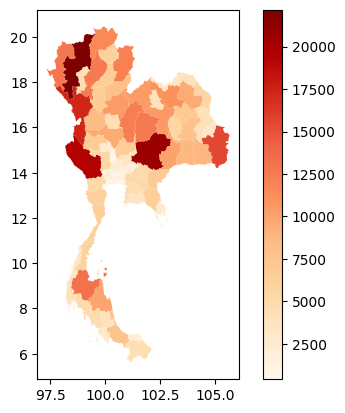

In [ ]:

import geopandas as gpd

# อ่านไฟล์ Shapefile
shapefile_path = '/content/drive/MyDrive/Colab Notebooks/tha_admin_boundaries.shp'
geo_data = gpd.read_file(shapefile_path)

# แสดงข้อมูลเบื้องต้น
print(geo_data.head())
print(geo_data.crs)

# แสดงผลข้อมูลบนแผนที่ โดยใช้คอลัมน์ 'area_sqkm'
geo_data.plot(column='area_sqkm', cmap='OrRd', legend=True)


## **4. การแสดงผลข้อมูล**
### **4.1 สร้างกราฟด้วย Matplotlib**  5 คะแนน
สร้างกราฟแสดงประชากรของแต่ละประเทศในภูมิภาค ASEAN โดยให้นักศึกษาทดลองหาข้อมูลเอง
    

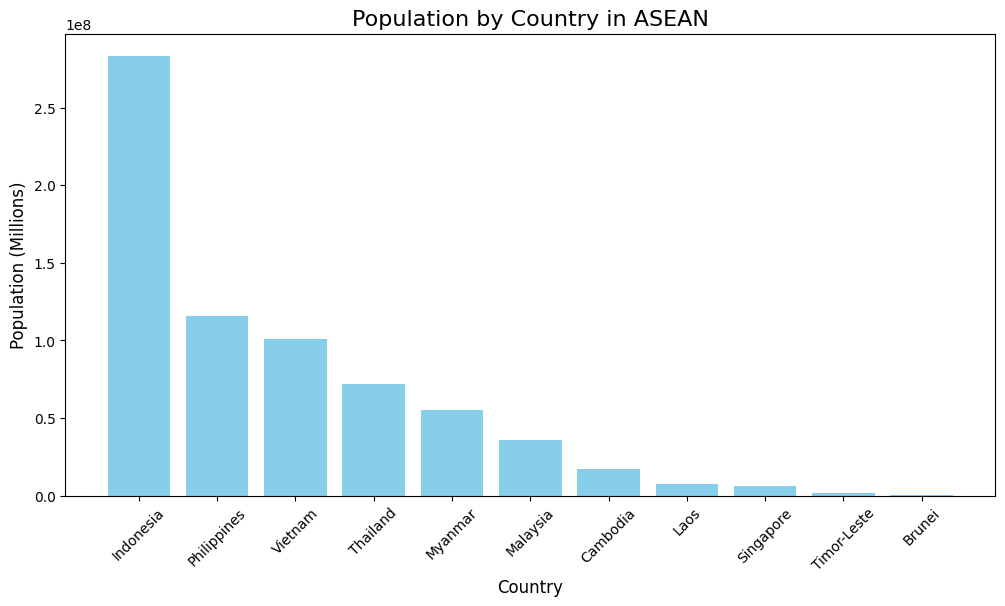

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ตัวอย่างการอ่านไฟล์ CSV
file_path = '/content/drive/MyDrive/Colab Notebooks/asean_population_reliable_2024.csv'
geo_df = pd.read_csv(file_path)

# สร้างกราฟแสดงประชากร
plt.figure(figsize=(12, 6)) # ปรับขนาดให้กว้างขึ้นเพื่อให้อ่านชื่อประเทศง่าย
plt.bar(geo_df['Country'], geo_df['Population_2024'], color='skyblue')
plt.title('Population by Country in ASEAN', fontsize=16 )
plt.xlabel('Country', fontsize=12 )
plt.ylabel('Population (Millions)', fontsize=12 ) # Adjusted label for clarity
plt.xticks(rotation=45) # เอียงชื่อประเทศเล็กน้อยถ้ามันซ้อนกัน
plt.show()


### **4.2 การรวมข้อมูลเชิงพื้นที่และตาราง**
รวมข้อมูล Shapefile กับข้อมูลประชากรเพื่อแสดงข้อมูลประชากรในแต่ละจังหวัด โดยให้นักศึกษาทดลองหาข้อมูลเอง
    

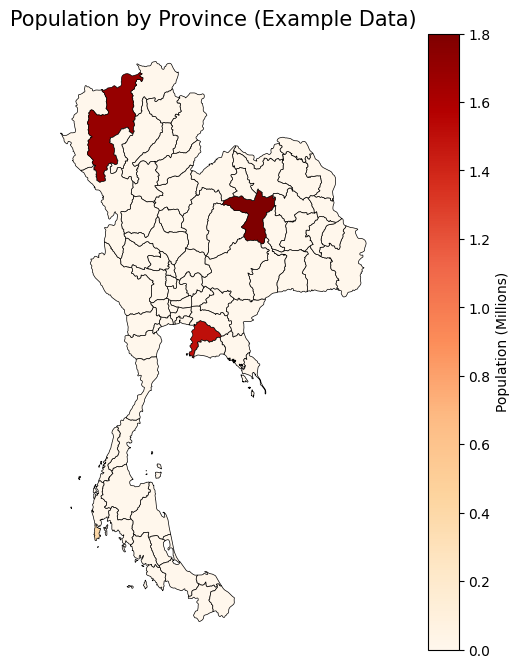

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load the Spatial Data (Shapefile/GeoJSON)
# For this example, we use a GeoJSON file hosted on GitHub.
# In a real scenario, use: geo_data = gpd.read_file('path/to/thailand_provinces.shp')
url = "https://raw.githubusercontent.com/apisit/thailand.json/master/thailand.json"
geo_data = gpd.read_file(url)

# Rename columns for clarity (e.g., ensuring we have a 'province_name' column)
geo_data = geo_data.rename(columns={'name': 'province_name'})

# Prepare the Tabular Data (Population)
# In a real scenario, use: df = pd.read_csv('population_data.csv')
data = {
    'Province': ['Bangkok', 'Chiang Mai', 'Phuket', 'Khon Kaen', 'Chon Buri'],
    'Population (Million)': [5.5, 1.7, 0.4, 1.8, 1.5]
}
df = pd.DataFrame(data)

# Merge the Data
# We merge the spatial data (geo_data) with the table (df).
# 'left_on': Column name in the map file (geo_data)
# 'right_on': Column name in the Excel/CSV file (df)
# how='left': Keeps all provinces in the map, even if they don't have population data.
merged_data = geo_data.merge(df, left_on='province_name', right_on='Province', how='left')

# Fill missing data (NaN) with 0 for better plotting
merged_data['Population (Million)'] = merged_data['Population (Million)'].fillna(0)

# Plot the Map
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

merged_data.plot(
    column='Population (Million)',
    cmap='OrRd',              # Color map: Orange to Red
    legend=True,              # Show the color scale
    legend_kwds={'label': "Population (Millions)"},
    missing_kwds={'color': 'lightgrey'}, # Color for provinces with no data
    edgecolor='black',        # Border color
    linewidth=0.5,
    ax=ax
)

plt.title('Population by Province (Example Data)', fontsize=15)
plt.axis('off') # Hide the X and Y axis
plt.show()


## **โจทย์สำหรับนักศึกษา** 15 คะแนน
1. ลองเพิ่มประเทศใหม่ใน DataFrame พร้อมคำนวณความหนาแน่นประชากร (5 คะแนน)
2. นำไฟล์ Shapefile ของพื้นที่อื่นมาแสดงผลใน GeoPandas (5 คะแนน)
3. ลองสร้างแผนที่ด้วยสีที่แตกต่างกันโดยใช้ค่าอื่น เช่น `area` หรือ `density` (5 คะแนน)

---

### **หมายเหตุ**
- ดาวน์โหลดข้อมูลจากแหล่ง Open Data เช่น [World Bank Open Data](https://data.worldbank.org) หรือ [Thailand Data Catalog](https://data.go.th)
- ใส่เครดิตแหล่งข้อมูลในรายงานของคุณ
    

In [14]:
import pandas as pd

# 1. สร้าง DataFrame ตัวอย่าง
data = {
    'ประเทศ': ['ไทย', 'ลาว', 'กัมพูชา', 'เวียดนาม','เมียนมาร์','อินโดนีเซีย','ฟิลิปปินส์','มาเลเซีย','สิงคโปร์','ติมอร์-เลสเต','บรูไน'],
    'ประชากร (ล้าน)': [69.8, 7.1, 16.5, 93.7, 55.1, 285.7, 117.7, 36.0, 5.9, 1.4, 0.47],
    'พื้นที่ (ตร.กม.)': [513120, 236800, 181035, 331210, 676578, 1904569, 300000, 330803, 734, 14874, 5765]
}
df = pd.DataFrame(data)

# 2. Create data for Australia
new_row = pd.DataFrame({
    'ประเทศ': ['ออสเตรเลีย'],
    'ประชากร (ล้าน)': [26.0],
    'พื้นที่ (ตร.กม.)': [7692024]
})

# 3. Append using pd.concat
df = pd.concat([df, new_row], ignore_index=True)

# 4. คำนวณความหนาแน่นประชากร
df['ความหนาแน่นประชากร (คน/ตร.กม.)'] = df['ประชากร (ล้าน)'] * 1000000 / df['พื้นที่ (ตร.กม.)']

# 5. แสดงข้อมูล
print(df)

          ประเทศ  ประชากร (ล้าน)  พื้นที่ (ตร.กม.)  \
0            ไทย           69.80            513120   
1            ลาว            7.10            236800   
2        กัมพูชา           16.50            181035   
3       เวียดนาม           93.70            331210   
4      เมียนมาร์           55.10            676578   
5    อินโดนีเซีย          285.70           1904569   
6     ฟิลิปปินส์          117.70            300000   
7       มาเลเซีย           36.00            330803   
8       สิงคโปร์            5.90               734   
9   ติมอร์-เลสเต            1.40             14874   
10         บรูไน            0.47              5765   
11    ออสเตรเลีย           26.00           7692024   

    ความหนาแน่นประชากร (คน/ตร.กม.)  
0                       136.030558  
1                        29.983108  
2                        91.142597  
3                       282.902086  
4                        81.439243  
5                       150.007692  
6                       392.333333  
7

In [5]:
import pandas as pd

# Existing df is available from previous cells
# 1. Create data for Australia
new_row = pd.DataFrame({
    'ประเทศ': ['ออสเตรเลีย'],
    'ประชากร (ล้าน)': [26.0],
    'พื้นที่ (ตร.กม.)': [7692024]
})

# 2. Append using pd.concat
df = pd.concat([df, new_row], ignore_index=True)

# 3. Recalculate population density for the entire DataFrame
df['ความหนาแน่นประชากร (คน/ตร.กม.)'] = df['ประชากร (ล้าน)'] * 1_000_000 / df['พื้นที่ (ตร.กม.)']

# 4. Display the updated DataFrame
print(df)

          ประเทศ  ประชากร (ล้าน)  พื้นที่ (ตร.กม.)  \
0            ไทย           69.80            513120   
1            ลาว            7.10            236800   
2        กัมพูชา           16.50            181035   
3       เวียดนาม           93.70            331210   
4      เมียนมาร์           55.10            676578   
5    อินโดนีเซีย          285.70           1904569   
6     ฟิลิปปินส์          117.70            300000   
7       มาเลเซีย           36.00            330803   
8       สิงคโปร์            5.90               734   
9   ติมอร์-เลสเต            1.40             14874   
10         บรูไน            0.47              5765   
11    ออสเตรเลีย           26.00           7692024   
12    ออสเตรเลีย           26.00           7692024   

    ความหนาแน่นประชากร (คน/ตร.กม.)  
0                       136.030558  
1                        29.983108  
2                        91.142597  
3                       282.902086  
4                        81.439243  
5                    

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


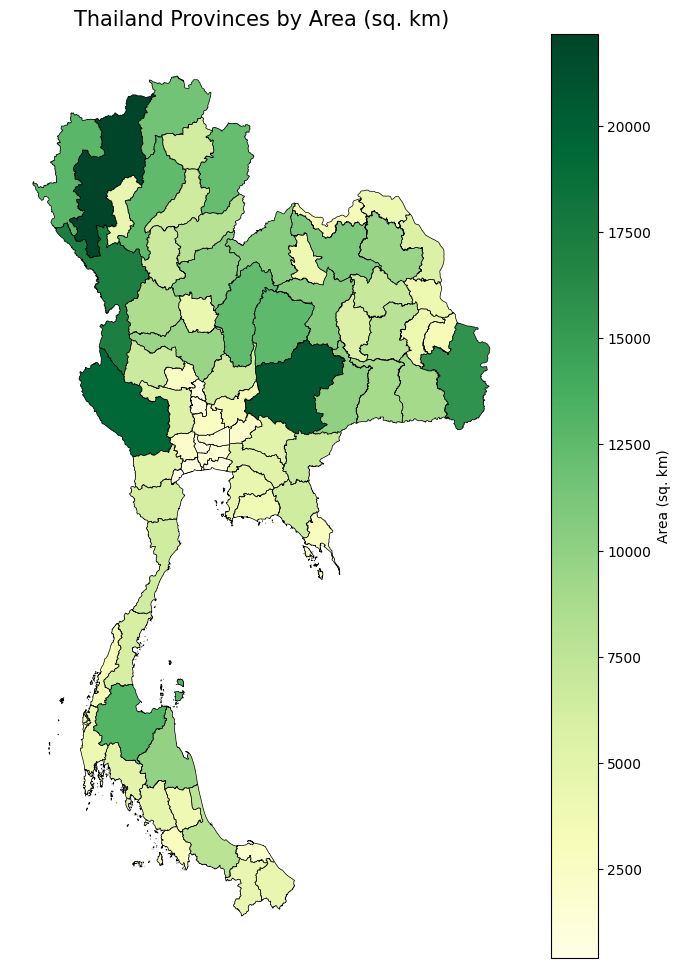

,ADM1_TH,area_sqkm
0,อำนาจเจริญ,3290.635392
1,อ่างทอง,943.956101
2,กรุงเทพมหานคร,1571.323599
3,บึงกาฬ,4012.682238
4,บุรีรัมย์,10095.554993


In [37]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. อ่านไฟล์ shapefile
shapefile_path = '/content/drive/MyDrive/Colab Notebooks/tha_admbnda_adm1_rtsd_20190221'

# 2. Read the correct layer identified earlier
layer_name = 'tha_admbnda_adm1_rtsd_20190221'
geo_admin = gpd.read_file(shapefile_path, layer=layer_name)

# 3. Calculate 'area_sqkm'
# Note: Since the CRS is EPSG:4326 (degrees), we project to a metric system (like EPSG:32647 for Thailand)
# to get accurate area in square meters, then convert to sq km.
geo_admin['area_sqkm'] = geo_admin.to_crs(epsg=32647).area / 10**6

# 4. Visualize the map based on 'area_sqkm'
fig, ax = plt.subplots(figsize=(10, 12))
geo_admin.plot(
    column='area_sqkm',
    cmap='YlGn',
    legend=True,
    legend_kwds={'label': "Area (sq. km)"},
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

plt.title('Thailand Provinces by Area (sq. km)', fontsize=15)
plt.axis('off')
plt.show()

# Display the head to verify the new column
display(geo_admin[['ADM1_TH', 'area_sqkm']].head())

# เครดิตแหล่งข้อมูลจาก OpenDevelopment แม่น้ำโขง

                  adm3_name       adm3_name1 adm3_name2 adm3_name3 adm3_pcode  \
0  Phraborom Maharatchawang  พระบรมมหาราชวัง       None       None   TH100101   
1       Wang Burapha Phirom   วังบูรพาภิรมย์       None       None   TH100102   
2          Wat Ratchabophit       วัดราชบพิธ       None       None   TH100103   
3                Samran Rat      สำราญราษฎร์       None       None   TH100104   
4          San Chaopho Suea   ศาลเจ้าพ่อเสือ       None       None   TH100105   

     adm2_name adm2_name1 adm2_name2 adm2_name3 adm2_pcode  ... area_sqkm  \
0  Phra Nakhon     พระนคร       None       None     TH1001  ...  1.536555   
1  Phra Nakhon     พระนคร       None       None     TH1001  ...  0.726134   
2  Phra Nakhon     พระนคร       None       None     TH1001  ...  0.211758   
3  Phra Nakhon     พระนคร       None       None     TH1001  ...  0.229786   
4  Phra Nakhon     พระนคร       None       None     TH1001  ...  0.150440   

  version lang lang1 lang2 lang3                ad

<Axes: >

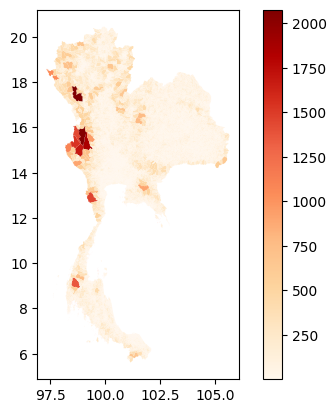

In [38]:
import geopandas as gpd

# อ่านไฟล์ Shapefile
shapefile_path = '/content/drive/MyDrive/Colab Notebooks/tha_admin_boundaries.shp/tha_admin1.shp'

# แสดงข้อมูลเบื้องต้น
print(geo_data.head())
print(geo_data.crs)

# แสดงผลข้อมูลบนแผนที่ โดยใช้คอลัมน์ 'area_sqkm'
geo_data.plot(column='area_sqkm', cmap='OrRd', legend=True)


In [25]:
import pyogrio

# List all available layers in the shapefile path
layers = pyogrio.list_layers(shapefile_path)
print("Available layers and their geometry types:")
print(layers)

Available layers and their geometry types:
[['tha_admbnda_adm1_rtsd_20190221' 'Polygon']]


Columns in the GeoDataFrame: ['Shape_Leng', 'Shape_Area', 'ADM1_EN', 'ADM1_TH', 'ADM1_PCODE', 'ADM1_REF', 'ADM1ALT1EN', 'ADM1ALT2EN', 'ADM1ALT1TH', 'ADM1ALT2TH', 'ADM0_EN', 'ADM0_TH', 'ADM0_PCODE', 'date', 'validOn', 'validTo', 'geometry']


,Shape_Leng,Shape_Area,ADM1_EN,ADM1_TH,ADM1_PCODE,ADM1_REF,ADM1ALT1EN,ADM1ALT2EN,ADM1ALT1TH,ADM1ALT2TH,ADM0_EN,ADM0_TH,ADM0_PCODE,date,validOn,validTo,geometry
0,3.927244,0.275313,Amnat Charoen,อำนาจเจริญ,TH37,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,NaT,"POLYGON ((104.95982 16.28359, 104.95986 16.283..."
1,1.739908,0.079210,Ang Thong,อ่างทอง,TH15,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,NaT,"POLYGON ((100.33319 14.79853, 100.33341 14.798..."
2,2.417227,0.131339,Bangkok,กรุงเทพมหานคร,TH10,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,NaT,"POLYGON ((100.61389 13.95462, 100.61428 13.954..."
3,4.414998,0.340784,Bueng Kan,บึงกาฬ,TH38,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,NaT,"POLYGON ((103.40497 18.44898, 103.40619 18.448..."
4,8.701860,0.844537,Buri Ram,บุรีรัมย์,TH31,None,None,None,None,None,Thailand,ประเทศไทย,TH,2019-02-18,2019-02-21,NaT,"POLYGON ((102.93029 15.79514, 102.93029 15.795..."


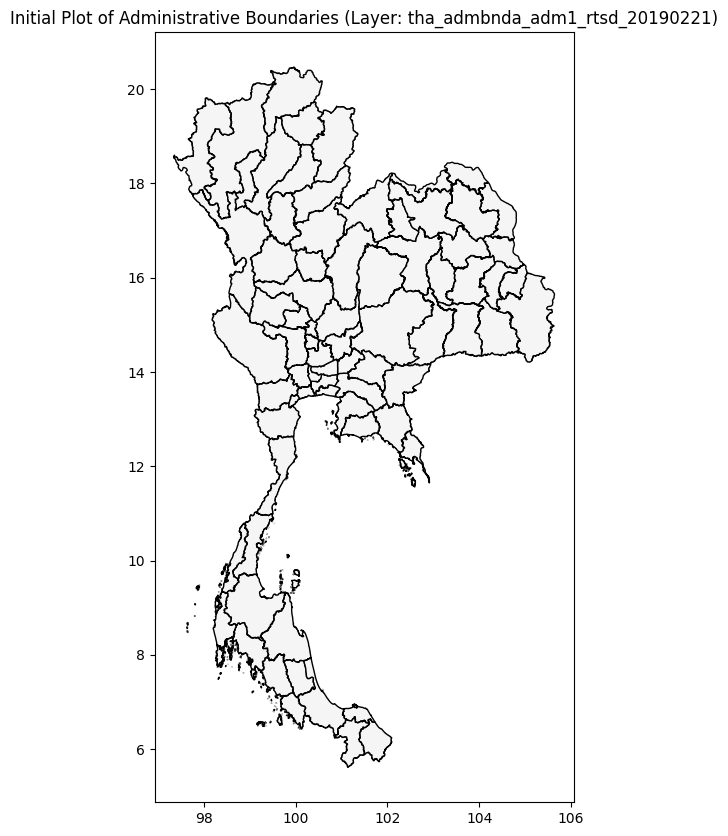

In [34]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the identified layer from the shapefile
layer_name = 'tha_admbnda_adm1_rtsd_20190221'
geo_data_valid = gpd.read_file(shapefile_path, layer=layer_name)

# Display the first few rows and list column names
print("Columns in the GeoDataFrame:", geo_data_valid.columns.tolist())
display(geo_data_valid.head())

# Perform an initial plot to verify spatial data
fig, ax = plt.subplots(figsize=(10, 10))
geo_data_valid.plot(ax=ax, edgecolor='black', color='whitesmoke')
plt.title('Initial Plot of Administrative Boundaries (Layer: ' + layer_name + ')')
plt.show()